In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [7]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

X_train = pad_sequences(X_train, maxlen=300)
X_test = pad_sequences(X_test, maxlen=300)

In [8]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=300),
    Bidirectional(LSTM(64)),
    Dense(1, activation='sigmoid')])

In [4]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [5]:
h = model.fit(
    X_train, y_train,
    epochs=4,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 113s 693ms/step - accuracy: 0.7519 - loss: 0.4895 - val_accuracy: 0.8424 - val_loss: 0.3599
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 108s 688ms/step - accuracy: 0.8948 - loss: 0.2669 - val_accuracy: 0.8718 - val_loss: 0.3456
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 109s 693ms/step - accuracy: 0.9184 - loss: 0.2127 - val_accuracy: 0.8634 - val_loss: 0.3375


Text(0.5, 1.0, 'Accuracy  vs  Validation Accuracy')

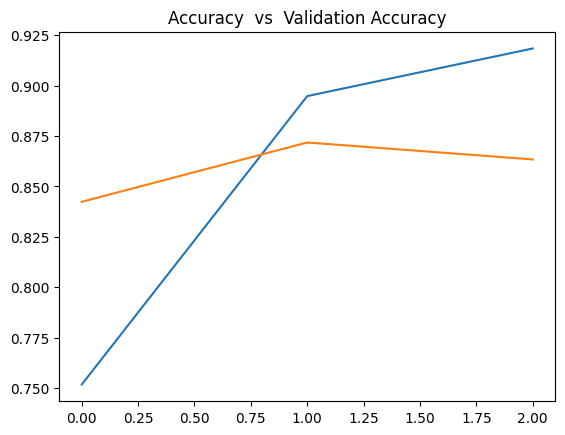

In [6]:
import matplotlib.pyplot as plt
plt.plot(h.history['accuracy'])
plt.plot(h.history['val_accuracy'])
plt.title('Accuracy  vs  Validation Accuracy')